In [1]:
!pip install pingouin seaborn openpyxl


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.8 kB ? eta -:--:--
     -------------------------------------- 40.8/40.8 kB 649.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/204.8 kB ? eta -:--:--
   ---------------------------------------- 204.8/204.8 kB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.1 MB 4.6 MB/s eta 0:00:02
   - -------------------------------------- 0.4/8.1 MB 4.0 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/8.1 MB 4.3 MB/s eta 0:00:02
   ---- ----------------------------------- 0.8/8.1 MB 4.4 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.1 MB 4.3 MB/s eta 0:00:02
   ----- ---------------------------------- 1.2/8.1 MB 4.5 MB/s eta 0:00:02
   ------- ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
%matplotlib inline
# Optional - better quality / interactive plots
%config InlineBackend.figure_format = 'retina'

In [1]:
# Cell 1 - imports & settings
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline               # Display plots directly in the notebook
%config InlineBackend.figure_format = 'retina'  # Higher resolution plots

sns.set(style="whitegrid", context="notebook", font_scale=1.1)  # Set plot style and scaling

pd.set_option("display.max_columns", 12)  # Limit number of displayed columns
pd.set_option("display.max_rows", 20)     # Limit number of displayed rows

print("Ready — libraries loaded")

Ready — libraries loaded


In [9]:
import pandas as pd  # Data manipulation and analysis

dfs = pd.read_excel(
    r"C:\Users\letri\OneDrive\Documents\Luis_Eduardo\2026\University\DATA 501\Lake Datasets\master_lake_data_long.xlsx",
    sheet_name=None
)  # Load all sheets from Excel into a dictionary of DataFrames

print("Unique lakes:", df['lake'].unique())  # List all unique lake names
print("\nUnique distance groups:", df['distance_group'].unique())  # List distance categories
print("\nParameter counts overall:\n", df['parameter'].value_counts().head(15))  # Top 15 most frequent parameters

# Key: which parameters have data in >1 distance group?
param_group = df.groupby('parameter')['distance_group'].nunique()  # Count unique distance groups per parameter
print("\nParameters with data in multiple distance groups:\n", 
      param_group[param_group > 1].sort_values(ascending=False))  # Filter parameters present in multiple groups

# Or full cross-tab
print("\nCross-tab parameter vs distance_group:\n", 
      pd.crosstab(df['parameter'], df['distance_group']))  # Frequency table of parameter vs distance group

Unique lakes: ['Gregoire' 'Isadore' 'Kearl' 'Mcclelland_Lake_All_Parameters_Master (1)'
 'Mildred' 'Namurlake_Data' nan]

Unique distance groups: ['Far' 'Near' 'Mid' nan]

Parameter counts overall:
 parameter
oxygen_dissolved_field_meter    437
calcium_dissolved               158
ph                              121
phosphorus_dissolved            103
nickel_total_recoverable         84
aluminum_total_recoverable       83
lead_total_recoverable           83
vanadium_dissolved               76
lead_dissolved                   76
copper_dissolved                 76
aluminum_dissolved               76
nickel_dissolved                 76
calcium_total_recoverable        61
phosphorus_total                 60
vanadium_total_recoverable       58
Name: count, dtype: int64

Parameters with data in multiple distance groups:
 parameter
aluminum_dissolved                     3
nickel_total_recoverable               3
vanadium_dissolved                     3
turbidity_ntu                          3

In [12]:
import pandas as pd

file_path = r"C:\Users\letri\OneDrive\Documents\Luis_Eduardo\2026\University\DATA 501\Lake Datasets\master_lake_data_long.xlsx"

# Load all sheets to see what's inside
dfs = pd.read_excel(file_path, sheet_name=None)

# Print overview of file structure
print("Sheets in the file:", list(dfs.keys()))  # List all sheet names
print("\n")

for sheet_name, temp_df in dfs.items():  # Loop through each sheet and its DataFrame
    print(f"Sheet: '{sheet_name}'")  # Display current sheet name
    print("Rows × Columns:", temp_df.shape)  # Show dimensions (rows, columns)
    print("Column names:", temp_df.columns.tolist())  # List column names
    print("First 3 rows (as string):")
    print(temp_df.head(3).to_string(index=False))  # Show first 3 rows without index
    print("\n" + "="*80 + "\n")  # Separator for readability

Sheets in the file: ['master_lake_data_long']


Sheet: 'master_lake_data_long'
Rows × Columns: (2012, 6)
Column names: ['sample_date', 'lake', 'distance_group', 'station', 'parameter', 'value']
First 3 rows (as string):
        sample_date     lake distance_group                station                  parameter  value
2017-08-23 08:19:00 Gregoire            Far GREGOIRE LAKE, PROFILE aluminum_total_recoverable    7.5
2017-08-23 08:32:00 Gregoire            Far GREGOIRE LAKE, PROFILE aluminum_total_recoverable    8.0
2025-08-20 09:00:00 Gregoire            Far GREGOIRE LAKE, PROFILE aluminum_total_recoverable   10.6




Loaded shape: (2012, 6)
Columns: ['sample_date', 'lake', 'distance_group', 'station', 'parameter', 'value']
Rows after cleaning: 2012

Unique distance groups: ['Far' 'Near' 'Mid']
Unique lakes: ['Gregoire' 'Isadore' 'Kearl' 'Mcclelland_Lake_All_Parameters_Master (1)'
 'Mildred' 'Namurlake_Data']

Top parameters:
 parameter
oxygen_dissolved_field_meter    437
calcium_dissolved               158
ph                              121
phosphorus_total_recoverable    110
phosphorus_dissolved            103
lead_total_recoverable           92
copper_total_recoverable         89
nickel_total_recoverable         84
aluminum_total_recoverable       83
vanadium_dissolved               76
nickel_dissolved                 76
lead_dissolved                   76
copper_dissolved                 76
aluminum_dissolved               76
calcium_total_recoverable        61
Name: count, dtype: int64

══════════════════════════════════════════════════════════════════════
aluminum_dissolved
══════════════════

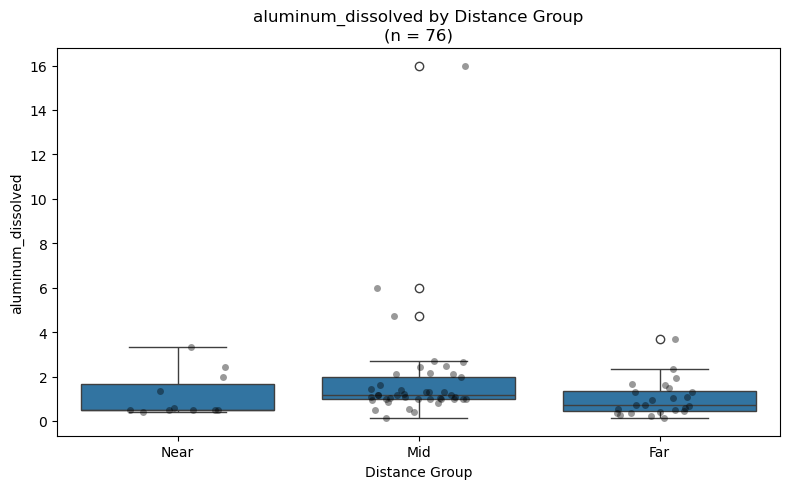

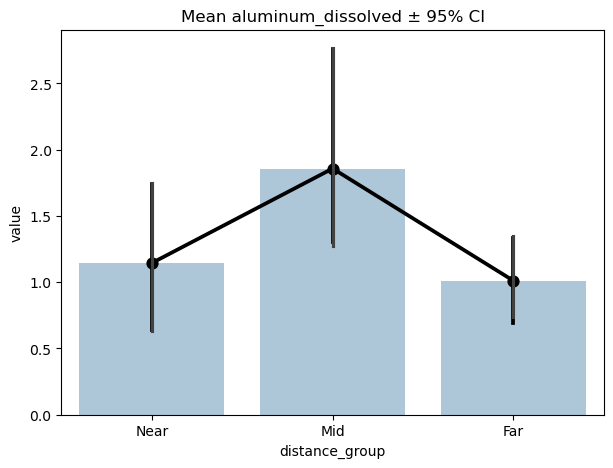


══════════════════════════════════════════════════════════════════════
aluminum_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     43
Far     29
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Far             0.787140  0.000050   False
Near            0.605694  0.000030   False
Mid             0.823277  0.000012   False

Levene (equal variances):
               W      pval  equal_var
levene  0.811082  0.447997       True

ANOVA:
           Source         SS  DF        MS       F   p_unc     np2
0  distance_group   345.0748   2  172.5374  1.4198  0.2478  0.0343
1          Within  9722.1221  80  121.5265     NaN     NaN     NaN

Main p-value (p_unc): 0.2478
→ Not significant (p ≥ 0.05) → no post-hoc needed


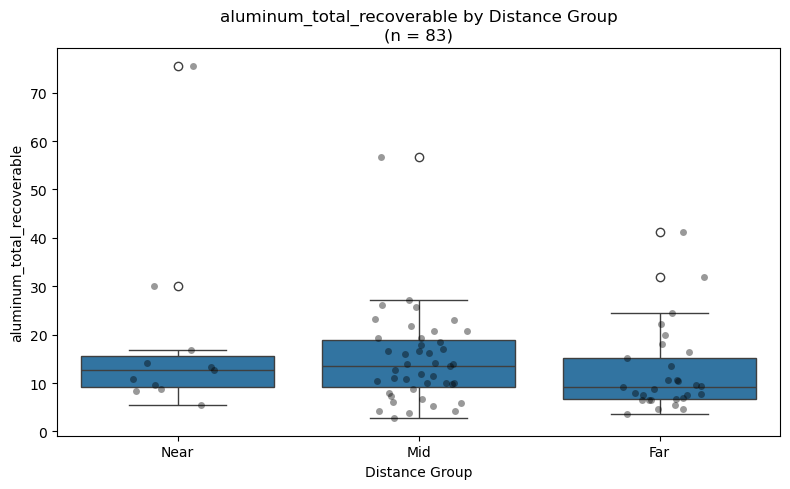

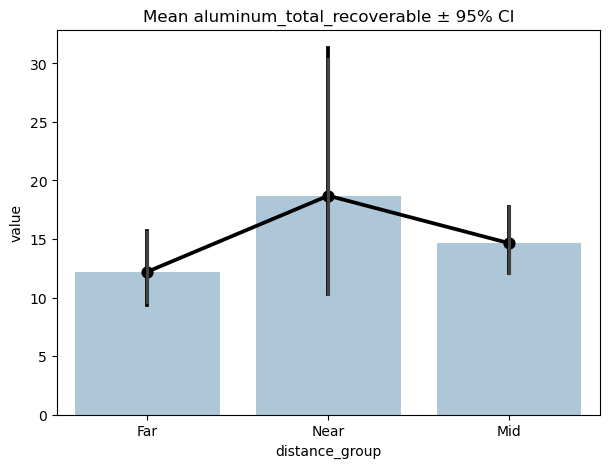


══════════════════════════════════════════════════════════════════════
calcium_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     83
Far     43
Near    32
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.790219  2.226360e-06   False
Near            0.918790  1.927987e-02   False
Mid             0.832672  2.879956e-08   False

Levene (equal variances):
                W          pval  equal_var
levene  51.612557  6.619491e-18      False

ANOVA:
           Source            SS   DF            MS         F  p_unc     np2
0  distance_group  7.313187e+08    2  3.656594e+08  118.4019    0.0  0.6044
1          Within  4.786851e+08  155  3.088291e+06       NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T  p_unc  p_corr   cohen
0  

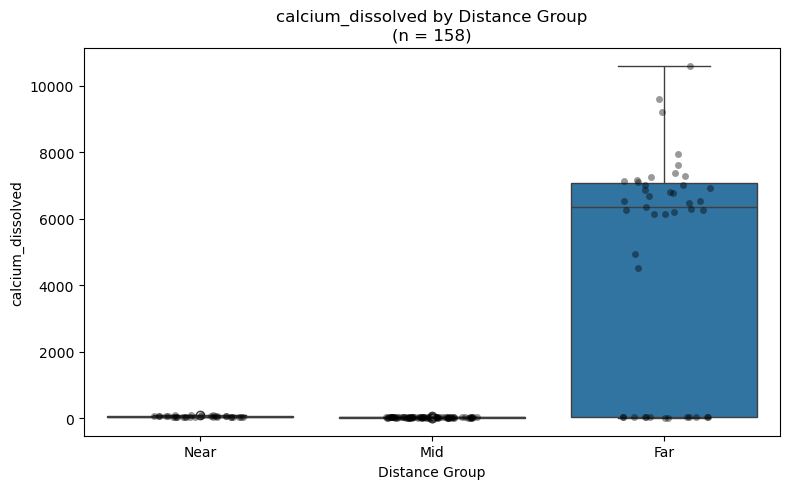

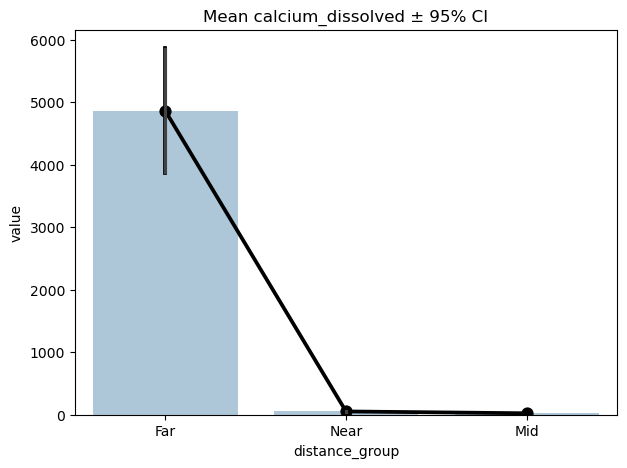


══════════════════════════════════════════════════════════════════════
calcium_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid    35
Far    26
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Far             0.741513  0.000021   False
Mid             0.773070  0.000006   False

Levene (equal variances):
               W      pval  equal_var
levene  13.86518  0.000441      False

ANOVA:
           Source            SS  DF            MS         F  p_unc     np2
0  distance_group  6.726596e+08   1  6.726596e+08  289.5301    0.0  0.8307
1          Within  1.370736e+08  59  2.323281e+06       NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A    B        T  p_unc   cohen
0  Far  Mid  14.6226    0.0  4.4055


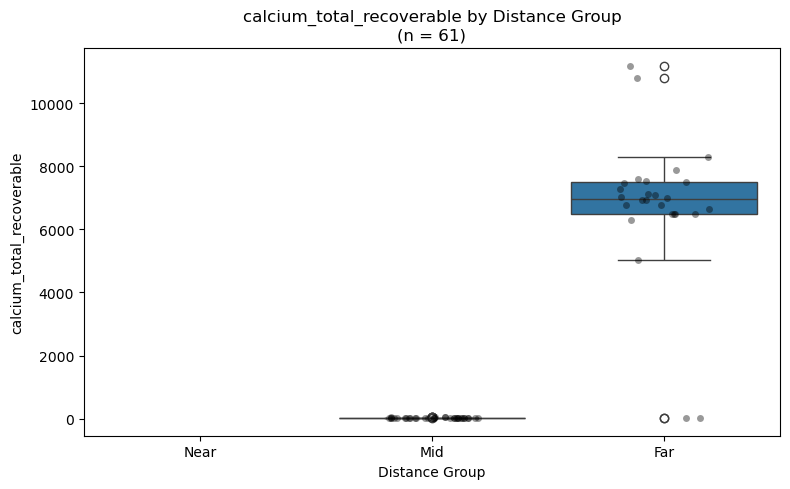

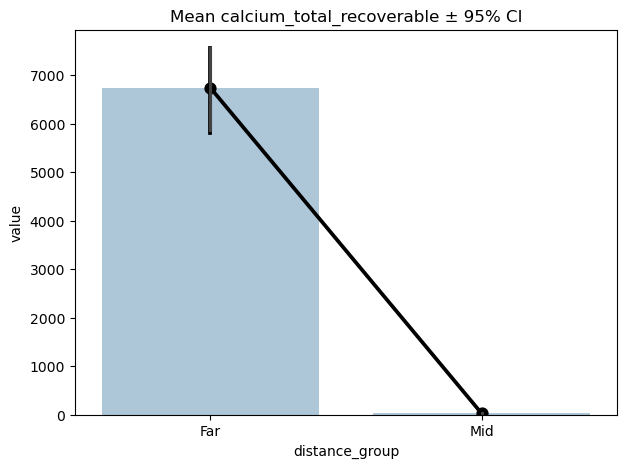


══════════════════════════════════════════════════════════════════════
copper_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     41
Far     24
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Near            0.962976  8.081815e-01    True
Mid             0.228554  2.198198e-13   False
Far             0.970473  6.786889e-01    True

Levene (equal variances):
               W      pval  equal_var
levene  0.269492  0.764524       True

ANOVA:
           Source       SS  DF      MS       F   p_unc     np2
0  distance_group   0.1556   2  0.0778  0.2054  0.8148  0.0056
1          Within  27.6478  73  0.3787     NaN     NaN     NaN

Main p-value (p_unc): 0.8148
→ Not significant (p ≥ 0.05) → no post-hoc needed


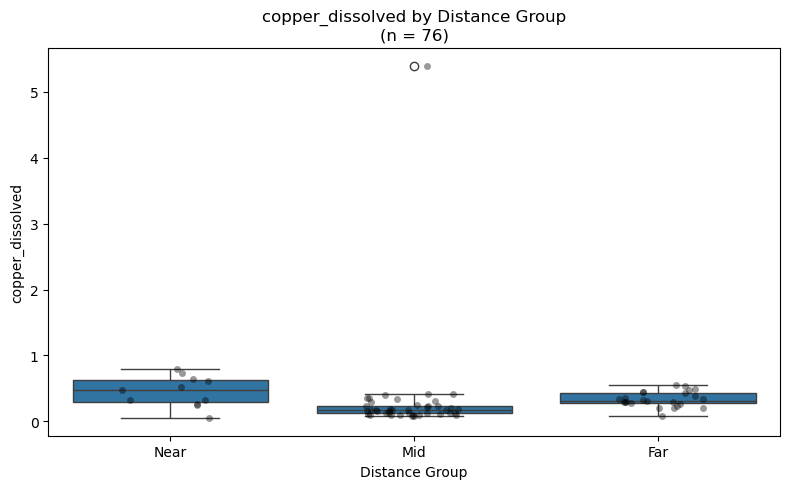

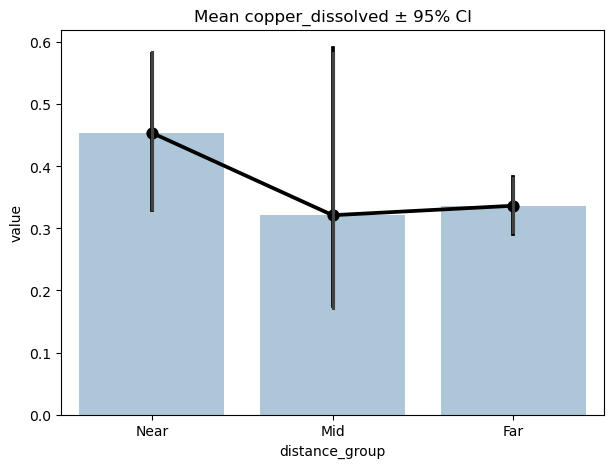


══════════════════════════════════════════════════════════════════════
copper_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     43
Far     30
Near    16
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.923948  3.399561e-02   False
Near            0.907154  1.047098e-01    True
Mid             0.221565  9.164301e-14   False

Levene (equal variances):
               W      pval  equal_var
levene  0.169458  0.844404       True

ANOVA:
           Source       SS  DF      MS       F   p_unc     np2
0  distance_group   0.0478   2  0.0239  0.0353  0.9653  0.0008
1          Within  58.2503  86  0.6773     NaN     NaN     NaN

Main p-value (p_unc): 0.9653
→ Not significant (p ≥ 0.05) → no post-hoc needed


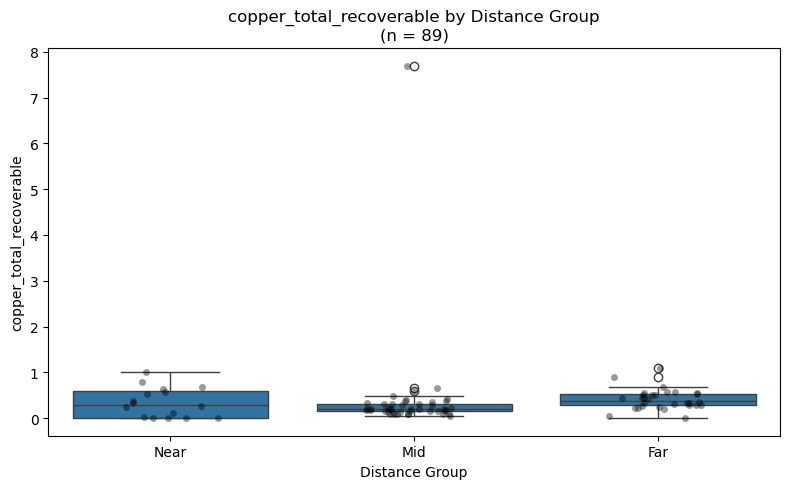

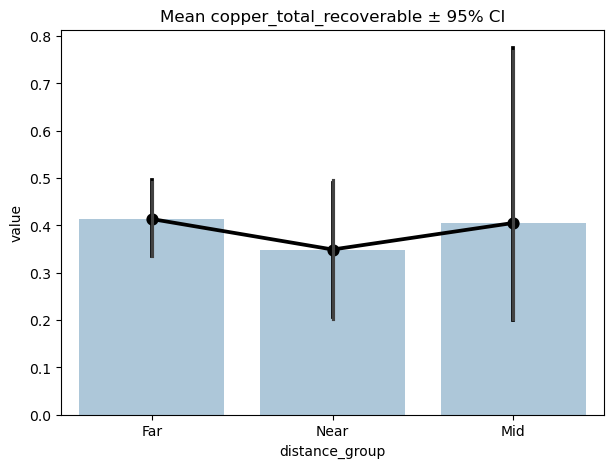


══════════════════════════════════════════════════════════════════════
lead_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     41
Far     24
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Near            0.805791  1.121187e-02   False
Mid             0.280071  6.370157e-13   False
Far             0.946479  2.270121e-01    True

Levene (equal variances):
               W      pval  equal_var
levene  0.928789  0.399649       True

ANOVA:
           Source      SS  DF      MS       F   p_unc     np2
0  distance_group  0.0356   2  0.0178  0.9183  0.4038  0.0245
1          Within  1.4152  73  0.0194     NaN     NaN     NaN

Main p-value (p_unc): 0.4038
→ Not significant (p ≥ 0.05) → no post-hoc needed


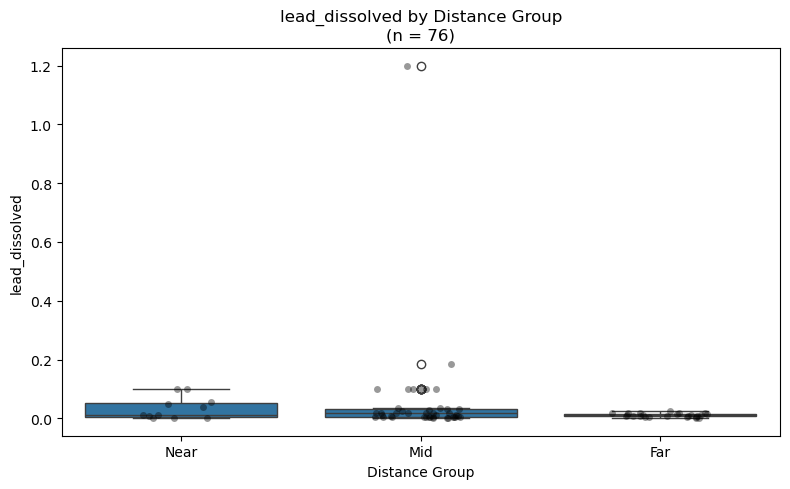

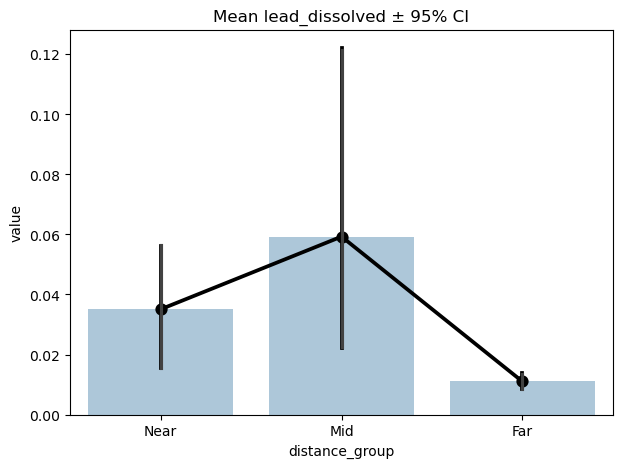


══════════════════════════════════════════════════════════════════════
lead_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     43
Far     29
Near    20
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.483732  5.296332e-09   False
Near            0.429895  7.836821e-08   False
Mid             0.348190  1.422048e-12   False

Levene (equal variances):
               W      pval  equal_var
levene  0.339431  0.713093       True

ANOVA:
           Source      SS  DF      MS       F   p_unc     np2
0  distance_group  0.0596   2  0.0298  0.5965  0.5529  0.0132
1          Within  4.4484  89  0.0500     NaN     NaN     NaN

Main p-value (p_unc): 0.5529
→ Not significant (p ≥ 0.05) → no post-hoc needed


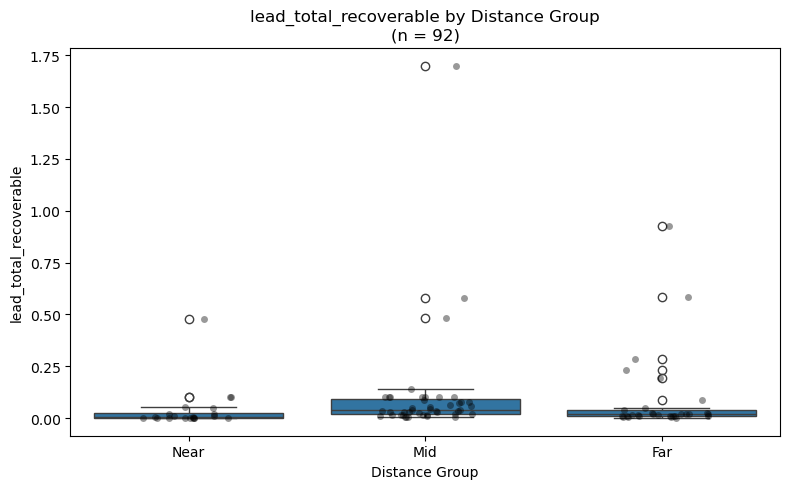

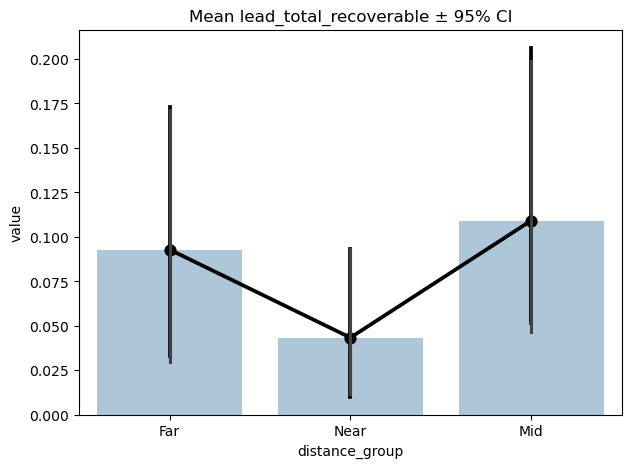


══════════════════════════════════════════════════════════════════════
nickel_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     41
Far     24
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Near            0.743680  0.001719   False
Mid             0.837775  0.000038   False
Far             0.954579  0.339397    True

Levene (equal variances):
               W      pval  equal_var
levene  1.765259  0.178369       True

ANOVA:
           Source      SS  DF      MS         F  p_unc    np2
0  distance_group  4.1414   2  2.0707  213.4156    0.0  0.854
1          Within  0.7083  73  0.0097       NaN    NaN    NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B        T  p_unc  p_corr   cohen
0  Far   Mid  19.3850  0.000   0.000  4.7118
1  Far  Near  21.8805  0.000  

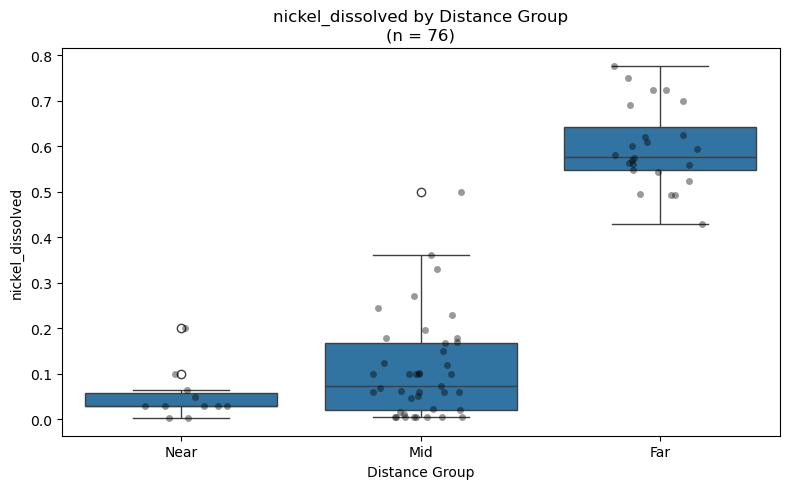

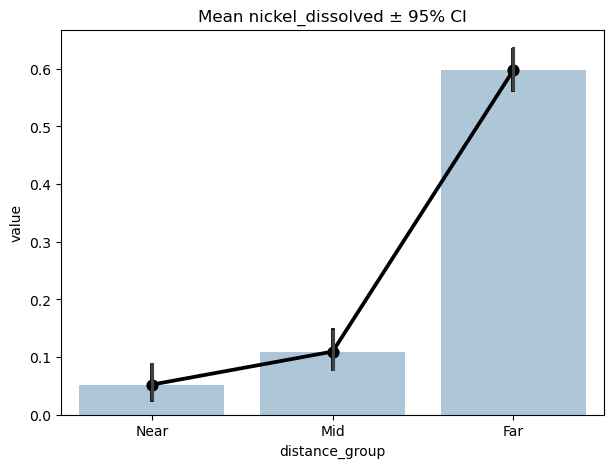


══════════════════════════════════════════════════════════════════════
nickel_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     43
Far     30
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.771038  2.030513e-05   False
Near            0.694263  3.947544e-04   False
Mid             0.715349  8.288422e-08   False

Levene (equal variances):
               W      pval  equal_var
levene  1.101966  0.337146       True

ANOVA:
           Source      SS  DF      MS        F  p_unc     np2
0  distance_group  4.8330   2  2.4165  68.7499    0.0  0.6293
1          Within  2.8471  81  0.0351      NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B        T   p_unc  p_corr   cohen
0  Far   Mid  10.7178  0.0000  0.0000  2.4111


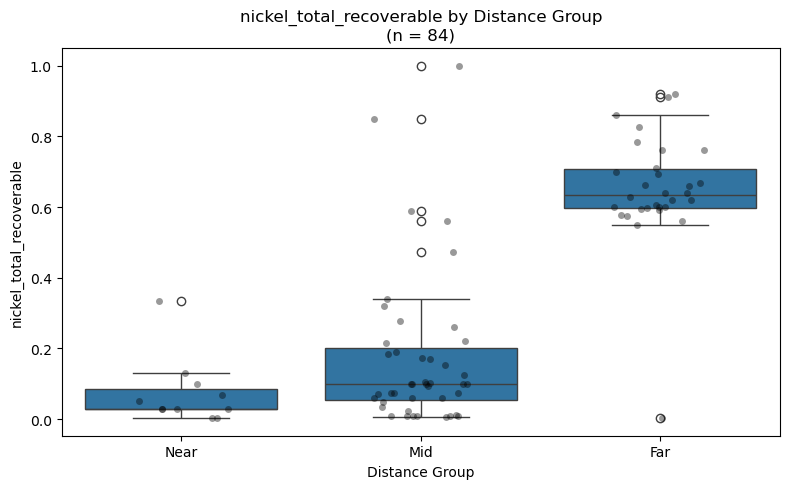

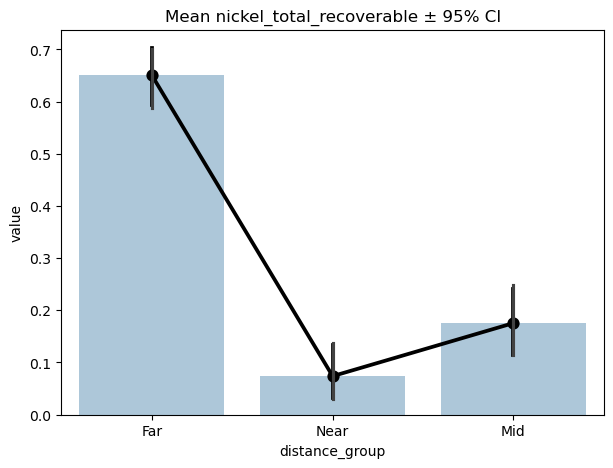


══════════════════════════════════════════════════════════════════════
nitrogen_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid    23
Far    18
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Mid             0.791063  0.000277   False
Far             0.910698  0.088505    True

Levene (equal variances):
                W      pval  equal_var
levene  32.339197  0.000001      False

ANOVA:
           Source           SS  DF           MS          F  p_unc     np2
0  distance_group  938074.6041   1  938074.6041  1376.6908    0.0  0.9725
1          Within   26574.5296  39     681.3982        NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A    B        T  p_unc    cohen
0  Far  Mid  32.7075    0.0  11.6764


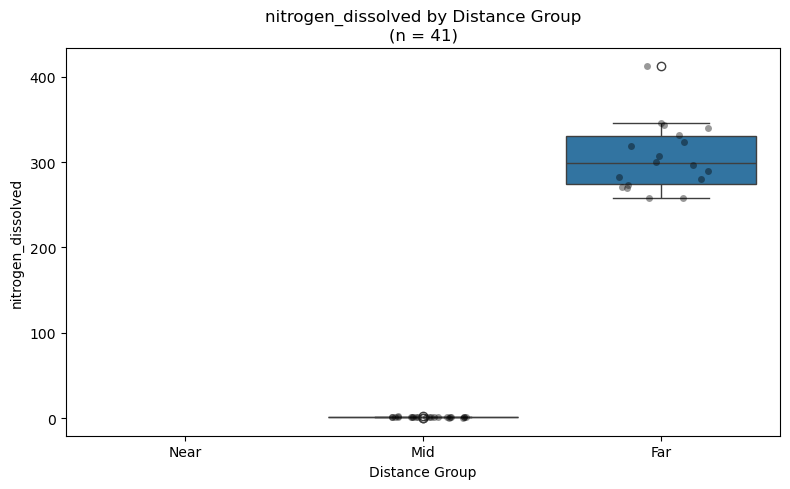

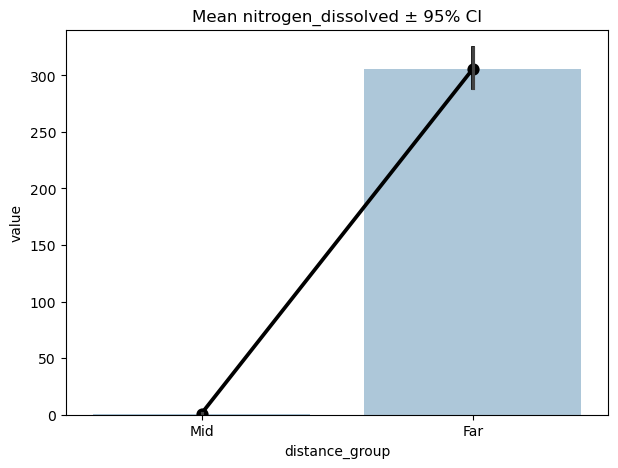


══════════════════════════════════════════════════════════════════════
phosphorus_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     56
Far     36
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.789539  1.016184e-05   False
Near            0.950100  6.452327e-01    True
Mid             0.611874  6.472818e-11   False

Levene (equal variances):
                W          pval  equal_var
levene  20.449775  3.585251e-08      False

ANOVA:
           Source         SS   DF        MS        F  p_unc     np2
0  distance_group  1239.7796    2  619.8898  42.0609    0.0  0.4569
1          Within  1473.7911  100   14.7379      NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid  6.7277  0

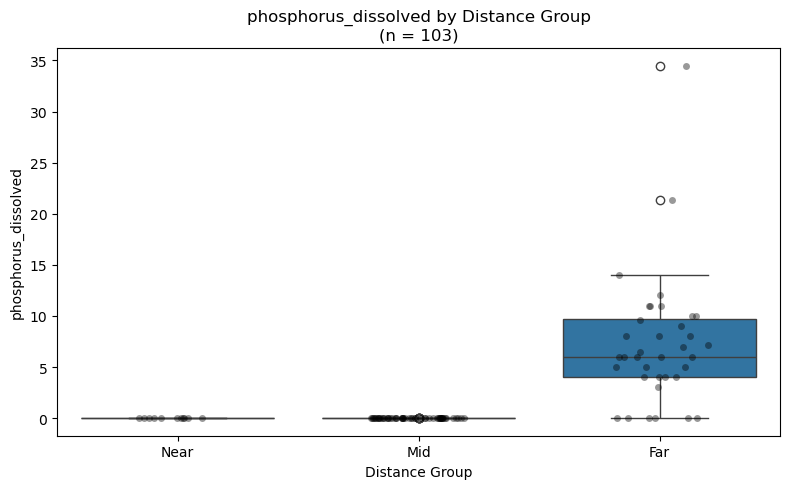

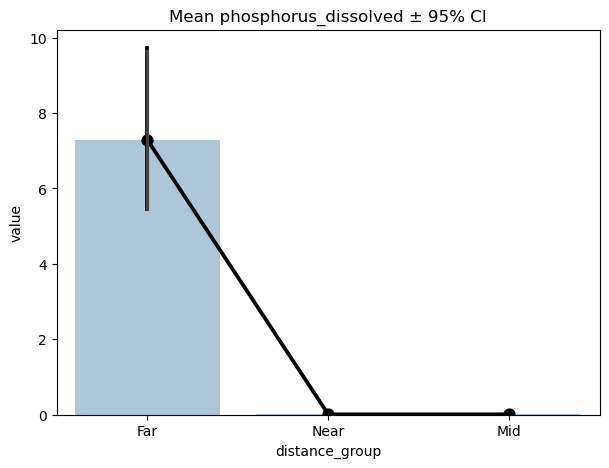


══════════════════════════════════════════════════════════════════════
phosphorus_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     56
Far     43
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Far             0.924652  0.007658   False
Near            0.678217  0.000246   False
Mid             0.972740  0.233919    True

Levene (equal variances):
               W      pval  equal_var
levene  4.234009  0.016995      False

ANOVA:
           Source      SS   DF      MS        F   p_unc   np2
0  distance_group  0.0015    2  0.0008  10.1876  0.0001  0.16
1          Within  0.0080  107  0.0001      NaN     NaN   NaN

Main p-value (p_unc): 0.0001
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -2.9029  0.0047  0.0141 -0.5456
1  Far  Near -2.80

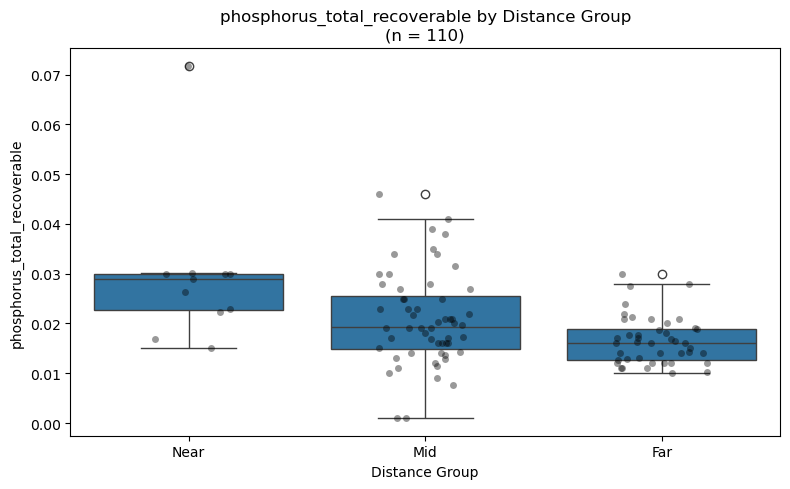

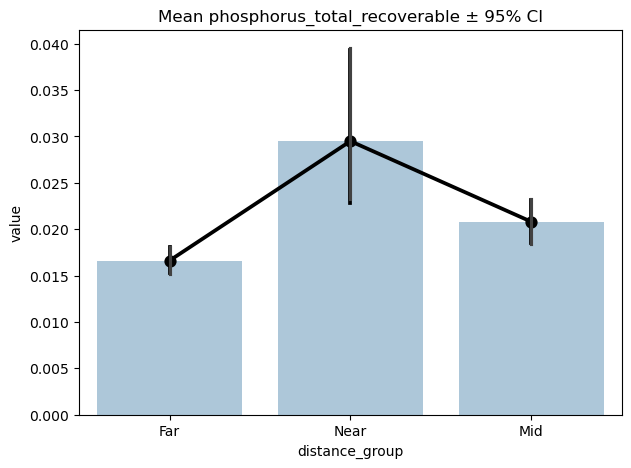


══════════════════════════════════════════════════════════════════════
vanadium_dissolved
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     41
Far     24
Near    11
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Near            0.926059  0.372374    True
Mid             0.945673  0.049383   False
Far             0.955923  0.362096    True

Levene (equal variances):
                W      pval  equal_var
levene  12.650054  0.000019      False

ANOVA:
           Source      SS  DF      MS        F  p_unc     np2
0  distance_group  0.2550   2  0.1275  26.8405    0.0  0.4237
1          Within  0.3468  73  0.0048      NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -9.0398  0.0000  0.0000 -1.8105
1  Far  Near -4.9754  0.00

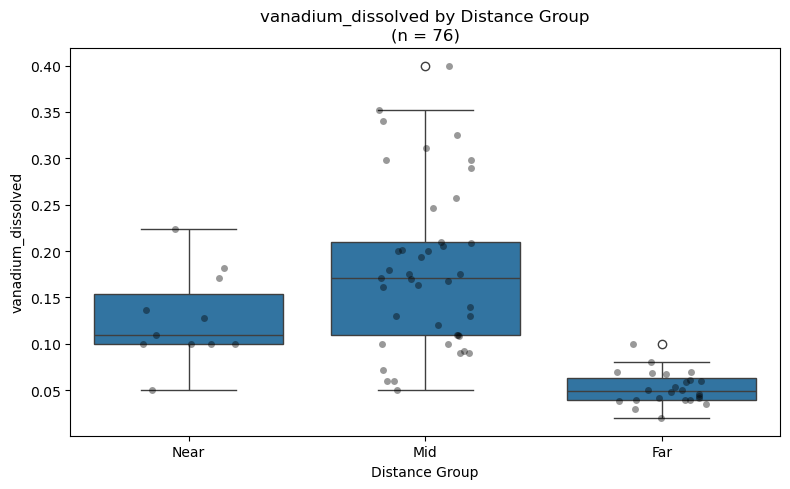

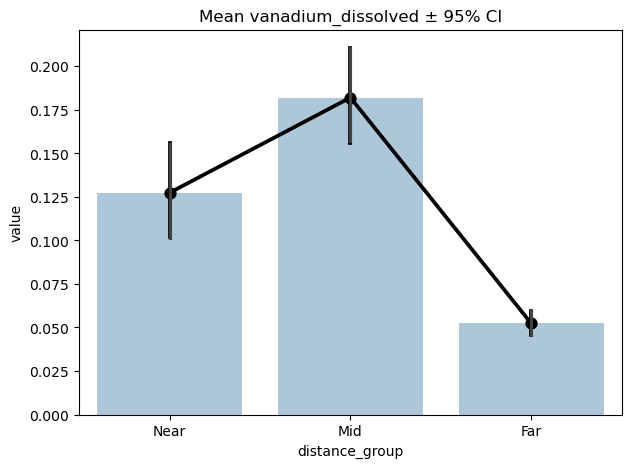


══════════════════════════════════════════════════════════════════════
vanadium_total_recoverable
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     43
Near    12
Far      4
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Far             0.794172  0.092173    True
Near            0.939641  0.493438    True
Mid             0.958003  0.117142    True

Levene (equal variances):
               W      pval  equal_var
levene  1.558576  0.219425       True

ANOVA:
           Source      SS  DF      MS       F  p_unc     np2
0  distance_group  0.1502   2  0.0751  6.9836  0.002  0.1996
1          Within  0.6021  56  0.0108     NaN    NaN     NaN

Main p-value (p_unc): 0.0020
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -2.9507  0.0400  0.1201 -1.1762
1  Far  Near -0.4819  0

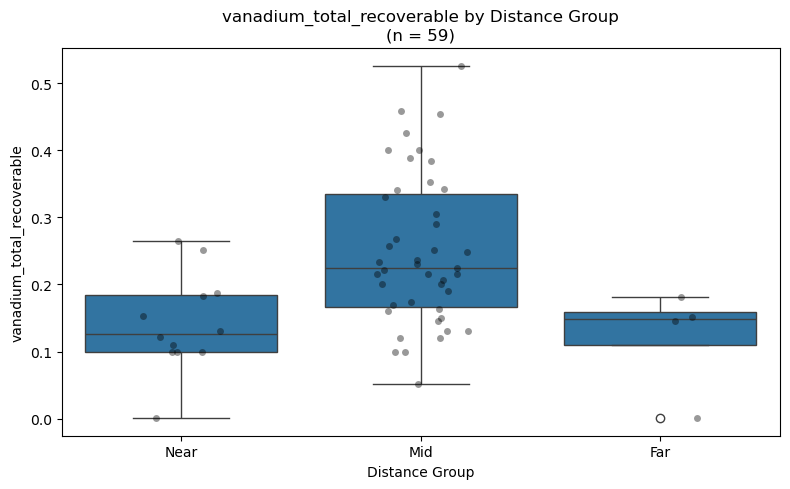

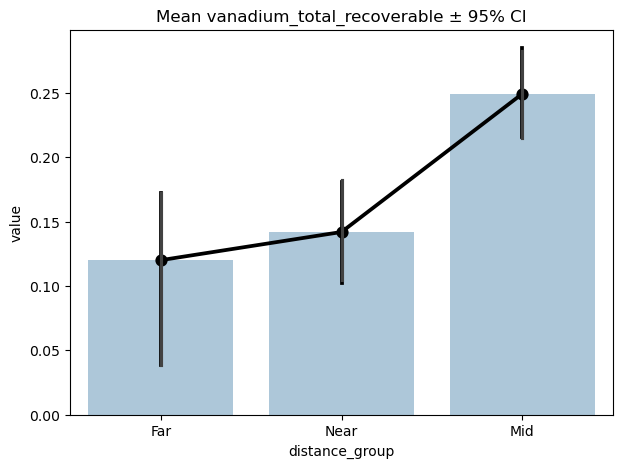


══════════════════════════════════════════════════════════════════════
ph
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     56
Far     43
Near    22
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.955426  9.421336e-02    True
Near            0.952526  3.541124e-01    True
Mid             0.801612  3.065375e-07   False

Levene (equal variances):
               W      pval  equal_var
levene  0.496972  0.609637       True

ANOVA:
           Source       SS   DF      MS        F  p_unc     np2
0  distance_group  18.0889    2  9.0445  37.4271    0.0  0.3881
1          Within  28.5153  118  0.2417      NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -7.1545  0.0000  0.0000 -1.3735
1  Far  Near -9.64

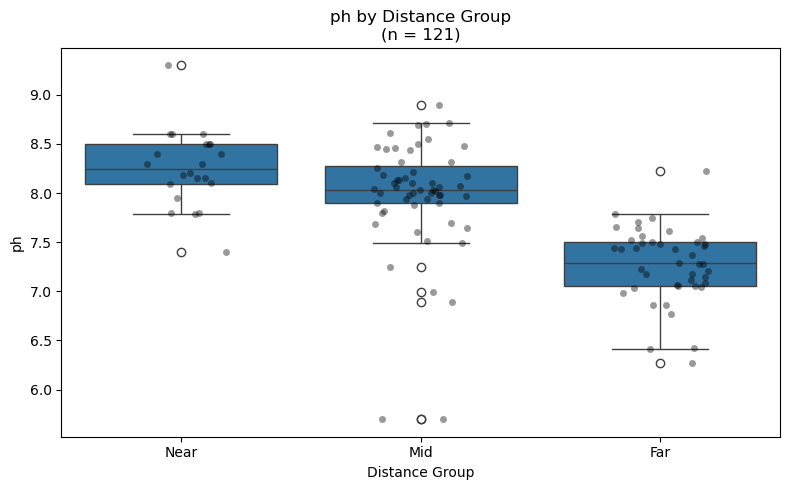

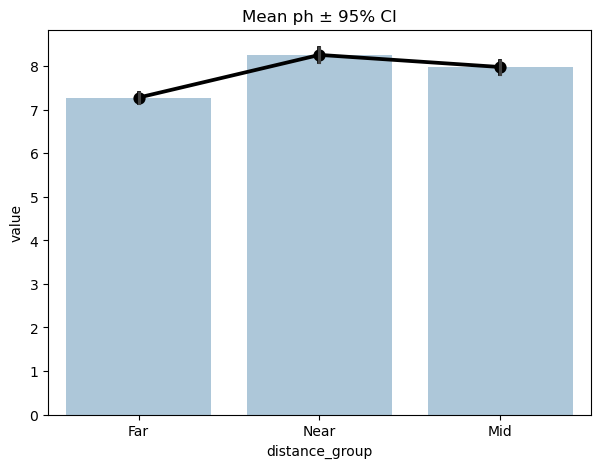


══════════════════════════════════════════════════════════════════════
turbidity_ntu
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     29
Far     24
Near     7
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.449774  1.898749e-08   False
Near            0.871464  1.911709e-01    True
Mid             0.803431  9.629478e-05   False

Levene (equal variances):
               W      pval  equal_var
levene  2.362594  0.103337       True

ANOVA:
           Source        SS  DF       MS       F   p_unc     np2
0  distance_group   24.4479   2  12.2240  6.2812  0.0034  0.1806
1          Within  110.9287  57   1.9461     NaN     NaN     NaN

Main p-value (p_unc): 0.0034
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -3.3571  0.0016  0.0047 -0.8857
1  F

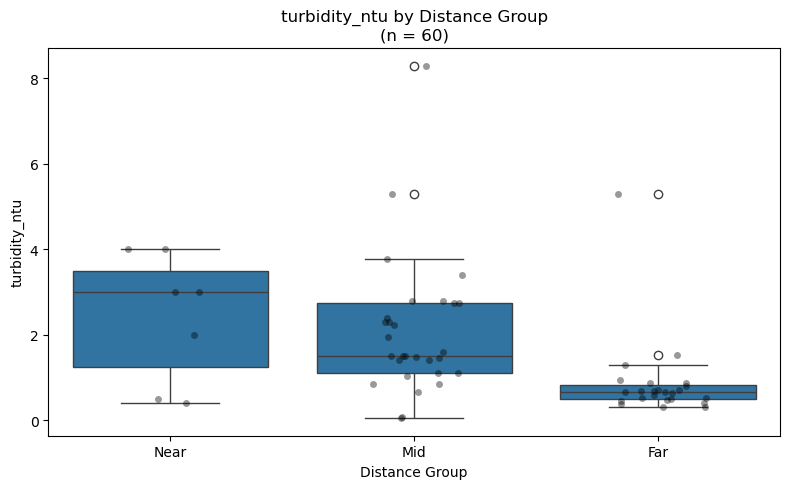

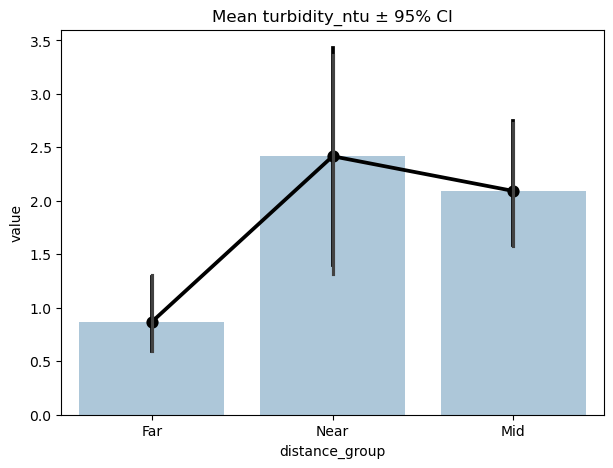


══════════════════════════════════════════════════════════════════════
oxygen_biochemical_demand
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     20
Near    10
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Near            0.834879  3.830257e-02   False
Mid             0.404449  4.844285e-08   False

Levene (equal variances):
               W      pval  equal_var
levene  1.190068  0.284615       True

ANOVA:
           Source       SS  DF      MS       F   p_unc     np2
0  distance_group   0.0882   1  0.0882  0.0423  0.8385  0.0015
1          Within  58.3455  28  2.0838     NaN     NaN     NaN

Main p-value (p_unc): 0.8385
→ Not significant (p ≥ 0.05) → no post-hoc needed


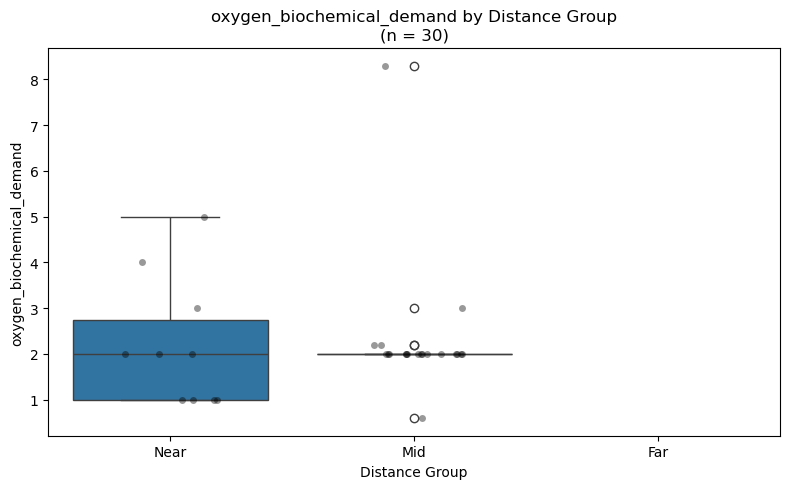

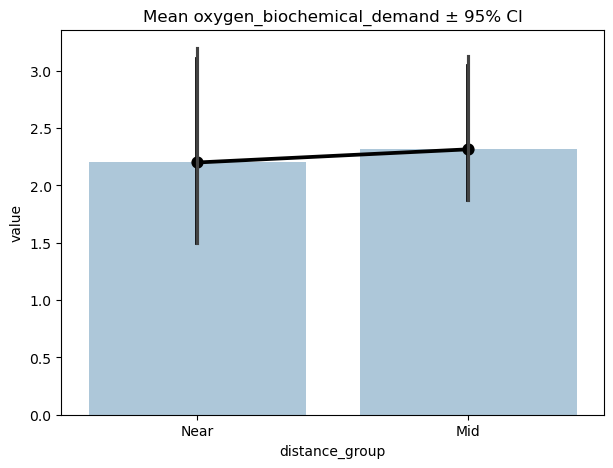


══════════════════════════════════════════════════════════════════════
oxygen_dissolved_field_meter
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Far     424
Near      8
Mid       5
Name: count, dtype: int64

Normality (Shapiro):
                       W          pval  normal
distance_group                                
Far             0.864281  9.500787e-19   False
Mid             0.904394  4.346440e-01    True
Near            0.897774  2.758774e-01    True

Levene (equal variances):
                W          pval  equal_var
levene  15.528257  3.065685e-07      False

ANOVA:
           Source         SS   DF       MS        F  p_unc     np2
0  distance_group    90.6312    2  45.3156  18.6739    0.0  0.0792
1          Within  1053.1793  434   2.4267      NaN    NaN     NaN

Main p-value (p_unc): 0.0000
→ Significant → running post-hoc

Post-hoc (Bonferroni corrected):

     A     B       T   p_unc  p_corr   cohen
0  Far   Mid -1

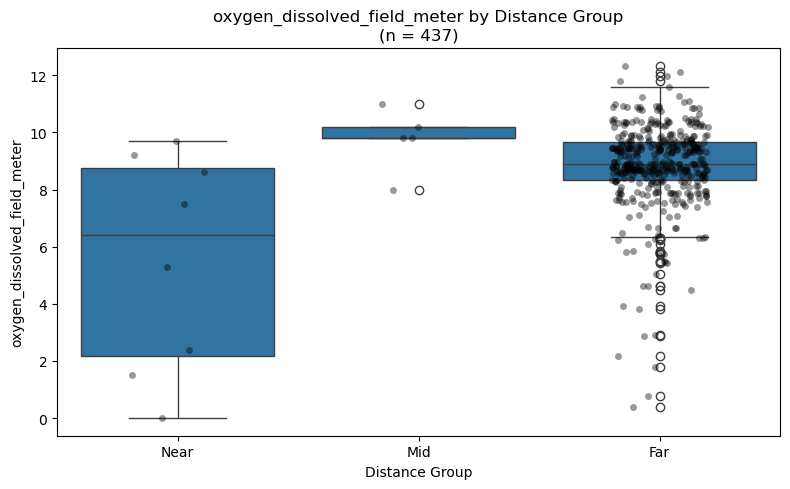

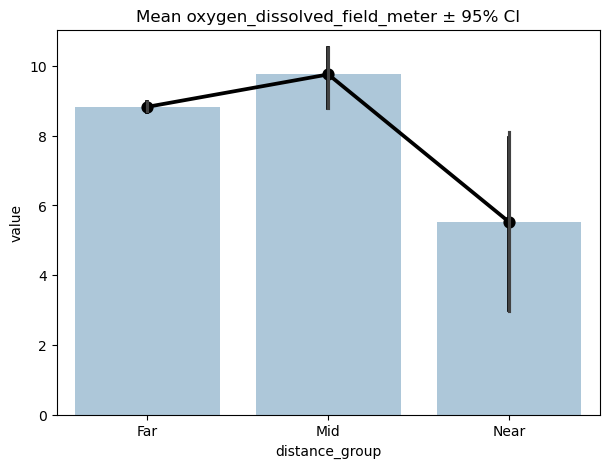


══════════════════════════════════════════════════════════════════════
oxygen_dissolved_percent_saturation
══════════════════════════════════════════════════════════════════════
Group sizes:
 distance_group
Mid     14
Far      3
Near     2
Name: count, dtype: int64

Normality (Shapiro):
                       W      pval  normal
distance_group                            
Near                 NaN       NaN   False
Mid             0.677206  0.000217   False
Far                  NaN       NaN   False

Levene (equal variances):
               W      pval  equal_var
levene  0.488654  0.622313       True

ANOVA:
           Source          SS  DF        MS       F   p_unc    np2
0  distance_group    126.3064   2   63.1532  0.0886  0.9156  0.011
1          Within  11399.6410  16  712.4776     NaN     NaN    NaN

Main p-value (p_unc): 0.9156
→ Not significant (p ≥ 0.05) → no post-hoc needed


C:\Users\letri\AppData\Roaming\Python\Python311\site-packages\pingouin\distribution.py:243: UserWarning: Group Near has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
C:\Users\letri\AppData\Roaming\Python\Python311\site-packages\pingouin\distribution.py:243: UserWarning: Group Far has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


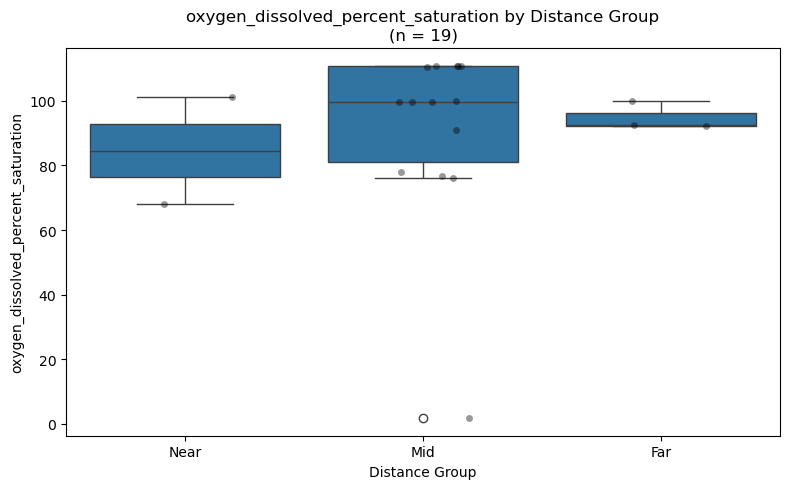

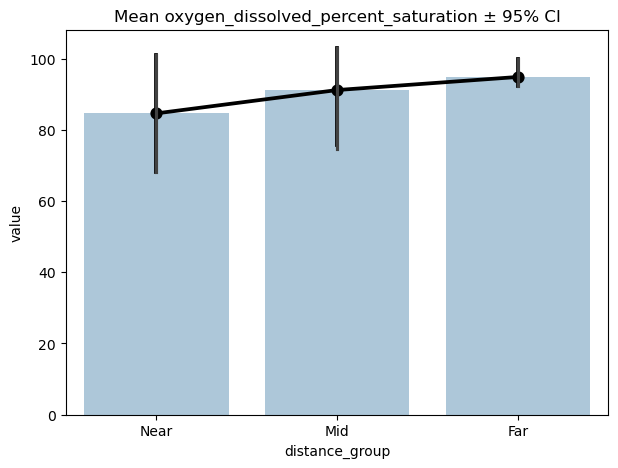

In [2]:
import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ────────────────────────────────────────────────────────────────
# Load the correct sheet
# ────────────────────────────────────────────────────────────────
file_path = r"C:\Users\letri\OneDrive\Documents\Luis_Eduardo\2026\University\DATA 501\Lake Datasets\master_lake_data_long.xlsx"
df = pd.read_excel(file_path, sheet_name='master_lake_data_long')

print("Loaded shape:", df.shape)  # Show dataset dimensions
print("Columns:", df.columns.tolist())  # List all column names

# Convert value column to numeric (handles strings/mixed types safely)
df['value'] = pd.to_numeric(df['value'], errors='coerce')  # Non-numeric → NaN

# Remove rows where 'value' is missing or invalid
df = df.dropna(subset=['value'])  # Clean dataset

print("Rows after cleaning:", len(df))  # Remaining row count
print("\nUnique distance groups:", df['distance_group'].unique())  # Distance categories
print("Unique lakes:", df['lake'].unique())  # Lake names
print("\nTop parameters:\n", df['parameter'].value_counts().head(15))  # Most common parameters

# Optional: filter only summer months (June–Sept) to reduce seasonal variation
df['month'] = pd.to_datetime(df['sample_date']).dt.month  # Extract month from date
df_summer = df[df['month'].isin([6, 7, 8, 9])].copy()  # Keep summer data only

# ────────────────────────────────────────────────────────────────
# Parameters to test
# ────────────────────────────────────────────────────────────────
params_to_test = [
    'aluminum_dissolved',
    'aluminum_total_recoverable',
    'calcium_dissolved',
    'calcium_total_recoverable',
    'copper_dissolved',
    'copper_total_recoverable',
    'lead_dissolved',
    'lead_total_recoverable',
    'nickel_dissolved',
    'nickel_total_recoverable',
    'nitrogen_dissolved',
    'phosphorus_dissolved',
    'phosphorus_total_recoverable',
    'vanadium_dissolved',
    'vanadium_total_recoverable',
    'ph',
    'turbidity_ntu',
    'oxygen_biochemical_demand',
    'oxygen_dissolved_field_meter',
    'oxygen_dissolved_percent_saturation'
]  # List of water quality parameters to analyze

# ────────────────────────────────────────────────────────────────
# Run ANOVA + plots for each parameter
# ────────────────────────────────────────────────────────────────
for param in params_to_test:
    print(f"\n{'═'*70}\n{param}\n{'═'*70}")  # Section header for each parameter
    
    d = df[df['parameter'] == param].copy()  # Filter data for current parameter (use df_summer if desired)
    
    if len(d) < 10 or d['distance_group'].nunique() < 2:  # Ensure enough data and at least 2 groups
        print("→ Not enough data or only one group → skipping")
        continue
    
    print("Group sizes:\n", d['distance_group'].value_counts())  # Sample size per group
    
    # Assumption checks for ANOVA
    print("\nNormality (Shapiro):")
    print(pg.normality(d, dv='value', group='distance_group'))  # Test normality per group
    
    print("\nLevene (equal variances):")
    print(pg.homoscedasticity(d, dv='value', group='distance_group'))  # Test equal variances
    
    # One-way ANOVA
    aov = pg.anova(d, dv='value', between='distance_group', detailed=True)  # Run ANOVA
    print("\nANOVA:")
    print(aov.round(4))  # Display results
    
    # Detect correct p-value column (handles different naming conventions)
    p_col = None
    for possible in ['p_unc', 'p-unc', 'pvalue', 'p']:
        if possible in aov.columns:
            p_col = possible
            break
    
    if p_col is not None and aov[p_col].notna().any():  # Ensure p-values exist
        p_main = aov[p_col].iloc[0]  # Extract main ANOVA p-value
        print(f"\nMain p-value ({p_col}): {p_main:.4f}")
        
        if p_main < 0.05:  # Significant result
            print("→ Significant → running post-hoc")
            try:
                posthoc = pg.pairwise_tests(
                    d,
                    dv='value',
                    between='distance_group',
                    padjust='bonf',  # Bonferroni correction
                    effsize='cohen'  # Effect size
                )
                
                if posthoc.empty:  # Handle empty results
                    print("→ Post-hoc table is empty (likely too few valid comparisons)")
                else:
                    print("\nPost-hoc (Bonferroni corrected):\n")
                    
                    # Dynamically select available columns
                    cols = ['A', 'B', 'T']
                    for c in ['p_unc', 'p-unc', 'p-corr', 'p_corr', 'cohen']:
                        if c in posthoc.columns:
                            cols.append(c)
                    
                    print(posthoc[cols].round(4))  # Display selected columns
                    
            except Exception as e:
                print("Post-hoc failed:", str(e))  # Catch errors
        else:
            print("→ Not significant (p ≥ 0.05) → no post-hoc needed")
    else:
        print("→ Could not find p-value column in ANOVA table")
        print("   Available columns:", aov.columns.tolist())
        print("   Group sizes for reference:\n", d['distance_group'].value_counts())
    
    # Boxplot visualization
    plt.figure(figsize=(8, 5))  # Set figure size
    sns.boxplot(x='distance_group', y='value', data=d, order=['Near', 'Mid', 'Far'])  # Distribution per group
    sns.stripplot(x='distance_group', y='value', data=d, color='black', alpha=0.4, jitter=0.2)  # Overlay raw points
    plt.title(f"{param} by Distance Group\n(n = {len(d)})")  # Plot title
    plt.ylabel(param)  # Y-axis label
    plt.xlabel("Distance Group")  # X-axis label
    plt.tight_layout()  # Improve spacing
    plt.show()  # Display plot

    # Mean + confidence interval plot
    plt.figure(figsize=(7,5))  # Set figure size
    sns.pointplot(x='distance_group', y='value', data=d, errorbar='ci', color='black', markers='o')  # Mean with CI
    sns.barplot(x='distance_group', y='value', data=d, alpha=0.4)  # Barplot overlay for context
    plt.title(f"Mean {param} ± 95% CI")  # Title
    plt.show()  # Display plot